In [1]:
from _helper_functions import cb
from _helper_functions import dprint
from _helper_functions import revcomp as dnarevcomp

import pickle
import matplotlib.pyplot as plt
import pandas as pd
import copy
import numpy as np
import scipy.stats as stats
import seaborn as sns
import itertools

In [2]:
with open('reference-files//OLSEnSeq2Name.pydict.pickle','rb') as f: OLSEnSeq2Name=pickle.load(f)
dprint(OLSEnSeq2Name)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6


In [3]:
OLSEnName2Seq={v:k for k,v in OLSEnSeq2Name.items()}
dprint(OLSEnName2Seq)

L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6 CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA


In [4]:
def can_be_converted_to_int(val):
    try: 
        int(val)
        return True
    except ValueError:
        return False

can_be_converted_to_int('1')

True

In [5]:
ori2flip={
    'g':'G',
    'G':'g',
    'e':'E',
    'E':'e'
}
def revcomp(phrase,orientation):
    
    # reverse 
    phrase=phrase[::-1]
    
    # complement
    rcPhrase=[]
    for pi in phrase:
        
        # skip if spacing
        if can_be_converted_to_int(pi): 
            rcPhrase.append(pi)
            continue
        
        # flip if you are considering ori
        if orientation: 
            pi=ori2flip[pi[0]]+pi[1:]
            rcPhrase.append(pi)
            
        elif not orientation:
            rcPhrase.append(pi)
            
    return tuple(rcPhrase)

revcomp(('G1', 10, 'E2'),orientation=False)

('E2', 10, 'G1')

In [6]:
TfbsOri2Name={
    'GF':'G',
    'GR':'g',
    'EF':'E',
    'ER':'e'
}


In [7]:
S1,S2,S3,S4,S5 = 'CATCTGAAGCTC','TA','TTTCGAA','TGCTC',''
G1R,G2R,G3F       = 'GTTATCTC','AATATCT','AAGATAGG'
G1F,G2F,G3R       = [dnarevcomp(i) for i in [G1R,G2R,G3F]]
E1F,E2F           = 'ACGGAAGT','AAGGAAAT'
E1R,E2R           = [dnarevcomp(i) for i in [E1F,E2F]]

SiteSeq2Name={
    S1 :'L1',
    G1R:'G1R',
    S2 :'L2',
    E1F:'E1F',
    S3 :'L3',
    E2F:'E2F',
    S4 :'L4',
    G2R:'G2R',
    S5 :'L5',
    G3F:'G3F',
    G1F:'G1F',
    E1R:'E1R',
    E2R:'E2R',
    G2F:'G2F',
    G3R:'G3R',
    'A':'L6'
}

SiteName2Seq={name:seq for seq,name in SiteSeq2Name.items()}


In [8]:

def parse_ord_ori_spc(sitelist):
    sitelist=sitelist.split('-')
    sentence=[]
    for sitei,site in enumerate(sitelist):
        
        # if spacer
        if site[0]=='L': 
            spacerLen=len(SiteName2Seq[site])+8
            
            # adjust for G2
            if sitei==len(sitelist)-1:     pass
            elif sitelist[sitei+1]=='G2F': spacerLen-=1
            elif sitelist[sitei-1]=='G2R': spacerLen-=1
                
            sentence.append(spacerLen)        
            
        # if tfbs
        else:
            siteWithOri=site[0]+site[2]
            siteWithOri=TfbsOri2Name[siteWithOri]
            sentence.append(siteWithOri)
            
    return sentence[1:-1] # remove flanking affs




In [9]:

def get_all_phrases(sentence,spacing,length):
    
    # If your phrases don't include spacing
    if spacing==False:
        phrase2count={}
        for phrase in itertools.combinations(sentence, length):
            if phrase not in phrase2count:
                phrase2count[phrase]=0
            phrase2count[phrase]+=1
        return phrase2count
    
    # If your phrases include spacing
    if spacing==True:
        phrase2count={}
        sentence_withoutSpacing=[site for site in sentence if type(site)==str]
        for phrase_ilist in itertools.combinations(range(len(sentence_withoutSpacing)), length):
            
            # Get the sentence with spacing
            phrase_ilist=[2*pi for pi in phrase_ilist]
            phrase_withSpacing=[]
            for i,pi in enumerate(phrase_ilist):
                
                # if you've reached the last binding site
                if i==len(phrase_ilist)-1:
                    phrase_withSpacing.append(sentence[pi])
                
                # if there are still other spacings to calculate
                else:
                    
                    # add the first site
                    phrase_withSpacing.append(sentence[pi])
                    
                    # determine the spacing
                    pi_next=phrase_ilist[i+1]
                    
                    # add spacing
                    spacingBetweenFirstLast=sum([s for s in sentence[pi:pi_next] if type(s)==int])
                    phrase_withSpacing.append(spacingBetweenFirstLast)
                
            phrase_withSpacing=tuple(phrase_withSpacing)
            if phrase_withSpacing not in phrase2count: 
                phrase2count[phrase_withSpacing]=0
            phrase2count[phrase_withSpacing]+=1
                
        return phrase2count
        

In [10]:
# example of using functions
sitelist='L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6'
sentence=parse_ord_ori_spc(sitelist)
print(sentence)
print()
get_all_phrases(sentence,spacing=True,length=2)

['g', 10, 'E', 15, 'E', 13, 'g', 7, 'G']



{('g', 10, 'E'): 1,
 ('g', 25, 'E'): 1,
 ('g', 38, 'g'): 1,
 ('g', 45, 'G'): 1,
 ('E', 15, 'E'): 1,
 ('E', 28, 'g'): 1,
 ('E', 35, 'G'): 1,
 ('E', 13, 'g'): 1,
 ('E', 20, 'G'): 1,
 ('g', 7, 'G'): 1}

# Load library data

In [11]:
####################################
# Choose a dataset to load!!
####################################

fn='01-Calculate-Enhancer-Activity-Levels/02-generated-tables//endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle'
allDF=pd.read_pickle(fn).set_index('wt-enhancer-seq')
allDF.head()

,enhancer-id,enhancer-sites,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
wt-enhancer-seq,,,,,,,
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,Otx-a WT,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0
CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,ORL351560,L1-G1F-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,0.856235,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-1.100699,"(0, -1)",0
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAGATATTAAGATAGGA,ORL108031,L1-G1R-L2-E1F-L3-E2F-L4-G2F-L5-G3F-L6,0.777169,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.706492,"(0, 0)",0
CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTCCTATCTTA,ORL414244,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3R-L6,NaN,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,-1.486866,"(0, -1)",0
CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,ORL280162,L1-G1R-L2-E1R-L3-E2F-L4-G2R-L5-G3F-L6,0.518839,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-1.322202,"(0, -1)",0


# Generate all organizations

In [12]:
# the first time you run this, generate all possible 2-mer and 3-mer order/orientation/spacing organizations

start dataframe
c2v={}
c2v['phrase']=[]
c2v['phrase-type']=[]
c2v['phrase-length']=[]
c2v['phrase-is-spacing']=[]

Type2Phrase2Enhancer2Count={}

spacing,parse_func,title = True, parse_ord_ori_spc,'parse_ord_ori_spc'
for length in [2,3]:
        
    print(length,title)
    
    if title not in Type2Phrase2Enhancer2Count:
        Type2Phrase2Enhancer2Count[title]={}
        
    orientation_bool= 'ori' in title
    
    setPhrases=set()
    for seq,sentence in OLSEnSeq2Name.items():
        sentence=parse_func(sentence)
        phrase2count=get_all_phrases(sentence,spacing,length)
        
        for phrase,count in phrase2count.items():
            
            # Check if revcomp has been detected. If so, adjusst phrase to look like rev comp.
            if revcomp(phrase,orientation_bool) in Type2Phrase2Enhancer2Count[title]:
                phrase=revcomp(phrase,orientation_bool)
                
            # Add phrase if not around
            if (phrase not in Type2Phrase2Enhancer2Count[title]):
                Type2Phrase2Enhancer2Count[title][phrase]={}
            
            if seq not in Type2Phrase2Enhancer2Count[title][phrase]:
                Type2Phrase2Enhancer2Count[title][phrase][seq]=0
            Type2Phrase2Enhancer2Count[title][phrase][seq]+=count
            
            setPhrases.add(phrase)
        
        
    for phrase in setPhrases:
        c2v['phrase'].append(phrase)
        c2v['phrase-type'].append(title)
        c2v['phrase-length'].append(length)
        c2v['phrase-is-spacing'].append(spacing)

with open('F05-Syntax-Features/Type2Phrase2Enhancer2Count.pydict.pickle','wb') as f: pickle.dump(Type2Phrase2Enhancer2Count,f,protocol=pickle.HIGHEST_PROTOCOL)

In [14]:
piDF=pd.DataFrame(c2v)
piDF.to_pickle(f'F05-Syntax-Features//1-all-phrases-possible.pd.df.pickle')

piDF.head()

# discover syntax features significantly enriched in active elements

In [15]:
# if starting over
with open('F05-Syntax-Features/Type2Phrase2Enhancer2Count.pydict.pickle','rb') as f: Type2Phrase2Enhancer2Count=pickle.load(f)


In [16]:
# if youre starting from here
piDF=pd.read_pickle('F05-Syntax-Features/1-all-phrases-possible.pd.df.pickle')
piDF.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing
0,"(E, 24, E)",parse_ord_ori_spc,2,True
1,"(E, 56, g)",parse_ord_ori_spc,2,True
2,"(g, 33, G)",parse_ord_ori_spc,2,True
3,"(G, 24, G)",parse_ord_ori_spc,2,True
4,"(g, 22, G)",parse_ord_ori_spc,2,True


In [17]:
# load  functional enhancers dependent on gata/ets

geDF=allDF.loc[allDF['enhancer-dependent-gata-ets']==1,:].copy(deep=True)
print(len(geDF))
geDF.head()

52139


,enhancer-id,enhancer-sites,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
wt-enhancer-seq,,,,,,,
CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTCCTATCTTA,ORL373222,L1-G1F-L2-E1F-L3-E2F-L4-G2R-L5-G3R-L6,1.249433,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-0.258002,"(1, -1)",1
CATCTGAAGCTCGAGATAACTAACTTCCGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA,ORL317857,L1-G1F-L2-E1R-L3-E2F-L4-G2R-L5-G3F-L6,1.375287,CATCTGAAGCTCGAAATAACTAACTTGCGTTTTCGAAAAGCAAATT...,NaN,"(1, -1)",1
CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATTGCTCAGATATTCCTATCTTA,ORL383871,L1-G1R-L2-E1R-L3-E2F-L4-G2F-L5-G3R-L6,1.614942,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-0.449367,"(1, -1)",1
CATCTGAAGCTCGAGATAACTAACTTCCGTTTTCGAAAAGGAAATTGCTCAGATATTCCTATCTTA,ORL190541,L1-G1F-L2-E1R-L3-E2F-L4-G2F-L5-G3R-L6,1.343622,CATCTGAAGCTCGAAATAACTAACTTGCGTTTTCGAAAAGCAAATT...,NaN,"(1, -1)",1
CATCTGAAGCTCGAGATAACTAACTTCCGTTTTCGAAATTTCCTTTGCTCAATATCTCCTATCTTA,ORL200984,L1-G1F-L2-E1R-L3-E2R-L4-G2R-L5-G3R-L6,1.336315,CATCTGAAGCTCGAAATAACTAACTTGCGTTTTCGAAATTTGCTTT...,NaN,"(1, -1)",1


In [18]:
active_seqs_dependent_gataets=set(geDF.index)
list(active_seqs_dependent_gataets)[:3]

['TTTCGAAACTTCCGTCATCTGAAGCTCCCTATCTTTAAATATCTAAGGAAATTGCTCGAGATAACA',
 'TGCTCACGGAAGTCATCTGAAGCTCAGATATTTAGAGATAACTTTCGAACCTATCTTAAGGAAATA',
 'TAAGATATTCATCTGAAGCTCACGGAAGTTTTCGAAGTTATCTCTGCTCCCTATCTTAAGGAAATA']

In [19]:
# analysis parameters
handle_activity='not_detected_skip' # do not include enhancers that are undetected in either RNA or DNA 
handle_activity_counts = 'num_activity_added_weighted_by_phrase_counts' # if the organization is found twice within the same element, count it twice

# Which activity to use
activityCol='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

confidentPos=1
confidentNeg=0

In [20]:
## Remove func variants not dependent on gata and ets

# what are all active variants?
active_seqs_all_gataets = set(allDF.loc[allDF[activityCol]>=confidentPos,:].index)

# what active variants not dependent on gata and ets
active_seqs_independent_gataets = active_seqs_all_gataets - active_seqs_dependent_gataets

# remove active variants not dependent on gata and ets
desired_seqs = set(allDF.index) - active_seqs_independent_gataets

# subset
allDF=allDF.loc[list(desired_seqs),:]
len(allDF)

431974

# Get data for all real phrases

In [21]:
# get real data for phrases
realDataList=[]

for phrase,title in zip(piDF['phrase'],piDF['phrase-type']):
    
    enActivityList=[]
    
    orientation_bool='ori' in title
    
    # You only need to consider the fwd because the dictionary has the enhancers mapped to both the fwd and rev motif already
    for enSeq in Type2Phrase2Enhancer2Count[title][phrase]:

        if handle_activity=='not_detected_skip':

            # skip if not detected
            if enSeq not in allDF.index: continue

            # add activity only once 
            if    handle_activity_counts=='num_activity_added_weighted_by_phrase_counts':
                for i in range(Type2Phrase2Enhancer2Count[title][phrase][enSeq]):
                    enActivityList.append(allDF.at[enSeq,activityCol])

            # add activity multiple times
            elif  handle_activity_counts=='one_activity_per_phrase':
                enActivityList.append(allDF.at[enSeq,activityCol])

            else: raise ValueError('paramter not acounted for')



        else: raise ValueError('parameter not accounted for 2')
    
    nFuncEns=sum([act>confidentPos for act in enActivityList])
    nNfuncEns=sum([act<confidentNeg for act in enActivityList])
    nNotConfident=len(enActivityList)-nFuncEns-nNfuncEns
    
    realDataList.append((nFuncEns,nNotConfident,nNfuncEns))
    
piDF['real-data']=realDataList
    

In [22]:
piDF.to_pickle(f'F05-Syntax-Features//2-all-phrases-possible-withRealData-50k.pd.df.pickle')


In [23]:
# if restarting 
piDF=pd.read_pickle(f'F05-Syntax-Features//2-all-phrases-possible-withRealData-50k.pd.df.pickle')
piDF.head()


,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data
0,"(E, 24, E)",parse_ord_ori_spc,2,True,"(297, 1183, 669)"
1,"(E, 56, g)",parse_ord_ori_spc,2,True,"(642, 2224, 1402)"
2,"(g, 33, G)",parse_ord_ori_spc,2,True,"(356, 1601, 921)"
3,"(G, 24, G)",parse_ord_ori_spc,2,True,"(776, 4788, 3197)"
4,"(g, 22, G)",parse_ord_ori_spc,2,True,"(2170, 8041, 4725)"


In [24]:
len(piDF)

9022

In [25]:
phraseKeyList=[]

for idx in piDF.index:
    phraseTuple=piDF.at[idx,'phrase']
    phraseTuple='_'.join([str(i) for i in phraseTuple])
    
    phraseType=piDF.at[idx,'phrase-type']
    phraseType=phraseType.replace('parse_','')
    
    phraseKey=f'{phraseType}={phraseTuple}'
    phraseKeyList.append(phraseKey)
    
    
piDF['phrase-key']=phraseKeyList
piDF=piDF.set_index('phrase-key')
piDF.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data
phrase-key,,,,,
ord_ori_spc=E_24_E,"(E, 24, E)",parse_ord_ori_spc,2,True,"(297, 1183, 669)"
ord_ori_spc=E_56_g,"(E, 56, g)",parse_ord_ori_spc,2,True,"(642, 2224, 1402)"
ord_ori_spc=g_33_G,"(g, 33, G)",parse_ord_ori_spc,2,True,"(356, 1601, 921)"
ord_ori_spc=G_24_G,"(G, 24, G)",parse_ord_ori_spc,2,True,"(776, 4788, 3197)"
ord_ori_spc=g_22_G,"(g, 22, G)",parse_ord_ori_spc,2,True,"(2170, 8041, 4725)"


In [26]:
# example of test

# lets say we have 100 marbles total

# we have 10 red marbles and 90 black marbles

# we sample 30 marbles

# what is the p value of getting 5 marbles? 
# (ie, what is probability of getting 5 or more red marbles assuming H0 of 100 marbles total with 10 red?)

# survival function allows us to get P(X≥k)

# sanity checked using this calculator https://stattrek.com/online-calculator/hypergeometric

M,n,N,k=100,10,30,5
stats.hypergeom.sf(k=k, M=M, n=n, N=N)

0.03876507128330702

In [27]:
# set parameters for hypergeometric
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.hypergeom.html

M      = len(allDF)                             # total number of objects            (ie total number enhancers)
n_func = sum(allDF[activityCol]>confidentPos)   # total number of type i objects     (ie total number of func ens)
n_nfun = sum(allDF[activityCol]<confidentNeg)   # total number of type i objects     (ie total number of nonfunc ens)

M,n_func,n_nfun


(431974, 52139, 143799)

In [28]:
# only consider elements contained within at least 50 elements
N_minthreshold=50

In [29]:
# Setting up effect size table
#
# Recall that...
#    n = total number functional enhancers in lib (50,643)
#    M = total number sequences in lib (407147)
#    N = number sequences with motif
#    k = number functional enhancers with motif

#######################################################
#           Func En (F)             Non Func Seq (N)
#######################################################
#
# Motif     Fm = k                     Nm = N-k 
#
#######################################################
#
# No Motif  Fn = n-k                  Nn = M - n - Nm
#
#######################################################

# Odds Ratio = OR = (Fm/Nm) / (Fn/Nn)
# Rel. Risk  = RR = (Fm/(Fm+Nm)) / (Fn/(Fn+Nn))

In [30]:
percentFuncBackground=n_func/M
percentNfunBackground=n_nfun/M

pvalsF =[] # p value of func enrichment
enrichF=[] # raw enrichments
orF=[] # odds ratios

for mi in piDF.index:
    numF,numU,numNF=piDF.at[mi,'real-data']
    
    N = numF+numU+numNF # sampled number of objects     (ie number of enhancers with motif)
    
    if N>=N_minthreshold:
        
        # Getting pvalue
        k_func = numF          # sampled number type i objects (ie number of enhancers with motif that are func)
        k_nfun = numNF         # sampled number type i objects (ie number of enhancers with motif that are non func)

        pvalsF.append(stats.hypergeom.sf(k=k_func, M=M, n=n_func, N=N))
        
        # Effect size as fold change
        percentFuncForeground = numF / N
        funcEnrich            = percentFuncForeground / percentFuncBackground
        enrichF.append(funcEnrich)
        
        # Calculate params for OR and RR
        Fm_f=k_func # Fm = k
        
        Nm_f = N-k_func # Nm = N-k
        
        Fn_f = n_func - k_func # Fn = n-k
        
        Nn_f = M - n_func - Nm_f # Nn = M - n - Nm
        
        # Effect size as OR
        OR_f = (Fm_f/Nm_f) / (Fn_f/Nn_f) # OR = (Fm/Nm) / (Fn/Nn)
                
        orF.append(OR_f)
        
    else:
        pvalsF .append(np.NaN)
        enrichF.append(np.NaN)
        orF.append(np.NaN)

        

In [31]:
piDF['hyp-func-p']  = pvalsF 

piDF['func-enrich']  = enrichF 

piDF['func-odds-ratio']       = orF 

piDF.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio
phrase-key,,,,,,,,
ord_ori_spc=E_24_E,"(E, 24, E)",parse_ord_ori_spc,2,True,"(297, 1183, 669)",6.418141e-03,1.145025,1.169246
ord_ori_spc=E_56_g,"(E, 56, g)",parse_ord_ori_spc,2,True,"(642, 2224, 1402)",2.807051e-09,1.246251,1.293464
ord_ori_spc=g_33_G,"(g, 33, G)",parse_ord_ori_spc,2,True,"(356, 1601, 921)",2.983456e-01,1.024835,1.028536
ord_ori_spc=G_24_G,"(G, 24, G)",parse_ord_ori_spc,2,True,"(776, 4788, 3197)",1.000000e+00,0.733843,0.703565
ord_ori_spc=g_22_G,"(g, 22, G)",parse_ord_ori_spc,2,True,"(2170, 8041, 4725)",2.623752e-20,1.203706,1.248682


In [32]:
# Remove tests with not enough counts to do proper test
keepList = piDF['hyp-func-p'].notnull()
statsDF  = piDF.loc[keepList,:].copy(deep=True)
len(statsDF)

9022

In [33]:
# Remove tests with <10% enrichment
enrichmentDeltaRequired_func=.1
FuncEnrichment    = (statsDF['func-enrich'   ]-1 >= enrichmentDeltaRequired_func)
statsDF=statsDF.loc[FuncEnrichment]

len(statsDF),'valid tests'

(3113, 'valid tests')

In [34]:
statsDF['hyp-func-p-bonf']  = statsDF['hyp-func-p']  .apply(lambda p:min(1, p*len(statsDF)))

In [35]:
sigLevel=0.05

# Write out stats

In [36]:
# save to pickle and csv
outDF=statsDF.sort_values('func-enrich',ascending=False)
outDF['phrase-type']=outDF['phrase-type'].apply(lambda s: s.replace('parse_',''))

# all phrase lengths
fn=f'F05-Syntax-Features/4-stats-all-phrases-possible-realData-50k_filtMotifs=ord_ori_spc_minenrichFUNC={enrichmentDeltaRequired_func}_minN={N_minthreshold}'
outDF.to_pickle(fn+'.pandas.df.pickle')
outDF.to_csv(fn+'.tsv',index=False,sep='\t')

In [37]:
sigmotifs= (statsDF['hyp-func-p-bonf']<sigLevel)
sigDF=statsDF.loc[sigmotifs,:].sort_values('func-enrich',ascending=False)
sigDF.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio,hyp-func-p-bonf
phrase-key,,,,,,,,,
ord_ori_spc=g_21_e_24_E,"(g, 21, e, 24, E)",parse_ord_ori_spc,3,True,"(63, 34, 7)",1.042766e-32,5.018826,11.206427,3.246130e-29
ord_ori_spc=g_13_e_24_E,"(g, 13, e, 24, E)",parse_ord_ori_spc,3,True,"(108, 73, 21)",1.030567e-46,4.429628,8.385350,3.208155e-43
ord_ori_spc=g_36_g_9_E,"(g, 36, g, 9, E)",parse_ord_ori_spc,3,True,"(162, 108, 42)",2.617632e-66,4.301851,7.889255,8.148688e-63
ord_ori_spc=g_15_E_22_E,"(g, 15, E, 22, E)",parse_ord_ori_spc,3,True,"(107, 85, 25)",6.657682e-42,4.085253,7.098879,2.072536e-38
ord_ori_spc=e_24_E_8_G,"(e, 24, E, 8, G)",parse_ord_ori_spc,3,True,"(105, 80, 29)",6.524524e-41,4.065093,7.029848,2.031084e-37


In [38]:
len(sigDF)

972

In [39]:
sigDF.to_pickle(f'F05-Syntax-Features/5-stats-sig-motifs-possible-realData_filtMotifs=ord_ori_spc_minenrichFUNC={enrichmentDeltaRequired_func}_minN={N_minthreshold}.pandas.df.pickle')


In [40]:
#!!!!!!!!!! if startring over
sigDF=pd.read_pickle(f'F05-Syntax-Features/5-stats-sig-motifs-possible-realData_filtMotifs=ord_ori_spc_minenrichFUNC=0.1_minN=50.pandas.df.pickle')
sigDF.head()


,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio,hyp-func-p-bonf
phrase-key,,,,,,,,,
ord_ori_spc=g_21_e_24_E,"(g, 21, e, 24, E)",parse_ord_ori_spc,3,True,"(63, 34, 7)",1.042766e-32,5.018826,11.206427,3.246130e-29
ord_ori_spc=g_13_e_24_E,"(g, 13, e, 24, E)",parse_ord_ori_spc,3,True,"(108, 73, 21)",1.030567e-46,4.429628,8.385350,3.208155e-43
ord_ori_spc=g_36_g_9_E,"(g, 36, g, 9, E)",parse_ord_ori_spc,3,True,"(162, 108, 42)",2.617632e-66,4.301851,7.889255,8.148688e-63
ord_ori_spc=g_15_E_22_E,"(g, 15, E, 22, E)",parse_ord_ori_spc,3,True,"(107, 85, 25)",6.657682e-42,4.085253,7.098879,2.072536e-38
ord_ori_spc=e_24_E_8_G,"(e, 24, E, 8, G)",parse_ord_ori_spc,3,True,"(105, 80, 29)",6.524524e-41,4.065093,7.029848,2.031084e-37


# Load Permuted Data (done in `F04ii_Syntax-Features-From-Permuted-Data.ipynb` notebook)

In [41]:
perm_statsDF=pd.read_pickle('F05-Syntax-Features-Permuted/4-permuted-stats-all-phrases-possible-realData-50k_minenrichFUNC=0.1_minN=50.pandas.df.pickle')
perm_statsDF.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio,hyp-func-p-bonf
phrase-key,,,,,,,,,
ord_ori_spc=G_24_g_28_E,"(G, 24, g, 28, E)",ord_ori_spc,3,True,"(28, 55, 38)",0.000211,1.917201,2.193988,0.419467
ord_ori_spc=E_28_G_29_E,"(E, 28, G, 29, E)",ord_ori_spc,3,True,"(27, 51, 44)",0.000569,1.833576,2.071041,1.000000
ord_ori_spc=E_21_G_29_E,"(E, 21, G, 29, E)",ord_ori_spc,3,True,"(26, 59, 34)",0.000850,1.810178,2.037197,1.000000
ord_ori_spc=g_23_G_32_E,"(g, 23, G, 32, E)",ord_ori_spc,3,True,"(25, 59, 34)",0.001643,1.755306,1.958805,1.000000
ord_ori_spc=g_25_e_32_E,"(g, 25, e, 32, E)",ord_ori_spc,3,True,"(25, 65, 30)",0.002111,1.726051,1.917557,1.000000


In [42]:
len(perm_statsDF.loc[perm_statsDF['hyp-func-p-bonf']<.05])

0

In [43]:
exclude=set([np.inf,-np.inf])
realPList=[-np.log10(min(1,p)) for p in statsDF['hyp-func-p-bonf'] if p not in  exclude]
fakeNewsPList=[-np.log10(min(1,p)) for p in perm_statsDF['hyp-func-p-bonf']  if p not in  exclude]

len(realPList),len(fakeNewsPList)

/scratch/solvason/job_6000881/ipykernel_3578992/1287582038.py:2: RuntimeWarning: divide by zero encountered in log10
  realPList=[-np.log10(min(1,p)) for p in statsDF['hyp-func-p-bonf'] if p not in  exclude]


(3113, 1951)

In [44]:
realPList=sorted(realPList)
fakeNewsPList=sorted(fakeNewsPList)

# Number of sig motifs in real data versus permuted data

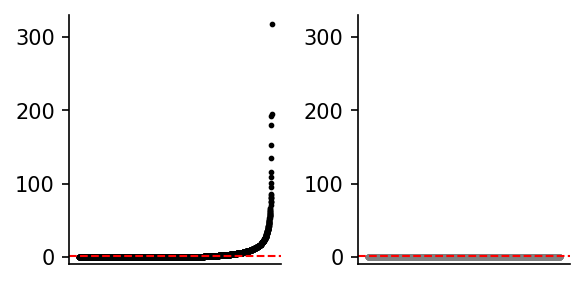

In [45]:
fig,ax=plt.subplots(1,2,figsize=(4,2),dpi=150)


ax[0].scatter(x=range(len(realPList)),y=realPList,color='black',label='Observed',       s=3)
ax[1].scatter(x=range(len(fakeNewsPList)),y=fakeNewsPList,color='grey',label='Permuted',s=3)

ax[0].axhline(-np.log10(.01),ls='--',color='red',lw=1)
ax[1].axhline(-np.log10(.01),ls='--',color='red',lw=1)

# ax.plot(realPList,color='lightgreen',label='Observed')
# ax.plot(fakeNewsPList,color='lightcoral',label='Permuted')

# ax.set_xlim(150000,240000)
# ax.legend()
# ax.set_ylabel('-log(P-value)')
for i in [0,1]:
    ax[i].set_xticks([],labels=[])
    yticks=list(range(0,400,100))
    ax[i].set_yticks(yticks,labels=yticks)

    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

    # ax[i].set_xlabel('Grammar Motifs\nOrdered By Significance')
    ax[i].set_ylim(-10,330)
    # ax[i].set_yscale('log')

plt.tight_layout()

out='000-manuscript-figs/06_MOT_20230919_Grammar-Motifs-50k__significances.svg'
plt.savefig(out,format='svg',transparent=True)
# plt.show()

